In [2]:
# %% [markdown]
# # IPO Listing Performance - 5 Year Analysis (Sep 2020 - Sep 2025)
# Run cell by cell in VS Code / Jupyter (the `# %%` markers) or run the whole file:
#     python ipo_analysis.py
# Needs: pandas, numpy, matplotlib, seaborn, scipy, scikit-learn, openpyxl
#
# What this script does
#   1. Load + profile the data
#   2. Clean it (every fix is logged, nothing is silently changed)
#   3. Engineer features
#   4. EDA: 8 business questions answered with tables + charts
#   5. Statistical tests + a small ML model (predict positive listing)
#   6. Export: clean CSV (Power BI), SQLite DB (SQL), summary tables, insights.md

# %% 1. Setup
import re
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
# Works on old and new seaborn: hide confidence-interval bars (old versions use ci=, new use errorbar=)
_sv = tuple(int(x) for x in sns.__version__.split(".")[:2])
NO_CI = {"errorbar": None} if _sv >= (0, 12) else {"ci": None}

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
SRC = BASE / "IPO_Listing_Performance_5yr.xlsx"
OUT = BASE / "output"
CHARTS, TABLES = OUT / "charts", OUT / "tables"
for p in (CHARTS, TABLES):
    p.mkdir(parents=True, exist_ok=True)

GAIN = "listing_gain_pct"          # main target metric
insights = []                       # collected as we go -> insights.md
cleaning_log = []                   # every data fix is written here


def save_fig(name):
    plt.tight_layout()
    plt.savefig(CHARTS / f"{name}.png", dpi=150)
    plt.close()


def save_table(df, name, index=True):
    df.to_csv(TABLES / f"{name}.csv", index=index)


# %% 2. Load + profile
raw = pd.read_excel(SRC)
print("Shape:", raw.shape)
print("Period:", raw["Listing_Date"].min().date(), "->", raw["Listing_Date"].max().date())
print("\nMissing values:\n", raw.isna().sum()[raw.isna().sum() > 0])
print("Duplicate IPO_ID:", raw["IPO_ID"].duplicated().sum())
print("Duplicate company names (names repeat, so IPO_ID is the key):",
      raw["Company_Name"].duplicated().sum())

# %% 3. Clean
df = raw.copy()
df.columns = (df.columns.str.strip().str.lower()
              .str.replace("%", "pct", regex=False)
              .str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_"))
df = df.rename(columns={"listing_gain_pct": GAIN, "return_1m_pct": "return_1m_pct"})

# 3a. Text columns: strip + standardise spelling/case (e.g. 'technology', 'Pharma&Healthcare')
df["sector_raw"] = df["sector"]
key = df["sector"].str.lower().str.replace(r"[^a-z]", "", regex=True)
canonical = df.groupby(key)["sector"].agg(lambda s: s.value_counts().index[0])
n = (df["sector"] != key.map(canonical)).sum()
df["sector"] = key.map(canonical)
cleaning_log.append(f"Sector: standardised {n} rows with inconsistent case/spelling")

# 3b. IPO_Type: derive from Exchange (SME exchanges = SME) - fixes contradicting labels
type_before = df["ipo_type"].str.lower().str.replace(" ", "")
df["ipo_type"] = np.where(df["exchange"].str.contains("SME"), "SME", "Mainboard")
n = (type_before != df["ipo_type"].str.lower()).sum()
cleaning_log.append(f"IPO_Type: fixed {n} rows (label was inconsistent / contradicted Exchange)")

# 3c. Negative issue size = sign error -> take absolute value, flag the row
neg = df["issue_size_cr"] < 0
df["flag_size_sign_fixed"] = neg
df.loc[neg, "issue_size_cr"] = df.loc[neg, "issue_size_cr"].abs()
cleaning_log.append(f"Issue_Size_Cr: {neg.sum()} negative values treated as sign errors (abs applied)")

# 3d. Issue_Price corrupted (~10x too high) in rows where the reported gain disagrees with
#     Close/Issue. Reported gain and 1M return agree with each other, so we trust them and
#     back-solve the price:  issue = close / (1 + gain)
calc_gain = (df["listing_close_price"] / df["issue_price"] - 1) * 100
bad_price = (calc_gain - df[GAIN]).abs() > 1
df["flag_price_fixed"] = bad_price
df.loc[bad_price, "issue_price"] = (df.loc[bad_price, "listing_close_price"]
                                    / (1 + df.loc[bad_price, GAIN] / 100)).round(2)
cleaning_log.append(f"Issue_Price: {bad_price.sum()} rows had a price inconsistent with the "
                    "reported gain -> price back-solved from close & gain")

# 3e. Missing listing gain -> recompute from prices (gain is fully derivable)
miss = df[GAIN].isna()
df["flag_gain_filled"] = miss
df.loc[miss, GAIN] = ((df["listing_close_price"] / df["issue_price"] - 1) * 100).round(2)
cleaning_log.append(f"Listing_Gain_%: {miss.sum()} missing values recomputed from Close/Issue price")

# 3f. Performance category: rebuild from the gain so it always matches
bins = [-np.inf, -3, 3, 15, 50, np.inf]
labels = ["Listing Loss", "Flat", "Modest Gain", "Strong Gain", "Bumper Listing"]
cat_new = pd.cut(df[GAIN], bins=bins, labels=labels, right=False).astype(str)
n = (cat_new != df["performance_category"]).sum()
df["performance_category"] = pd.Categorical(cat_new, categories=labels, ordered=True)
cleaning_log.append(f"Performance_Category: rebuilt from gain thresholds ({n} rows changed)")

# 3g. Genuinely missing (cannot be derived) -> left as NaN and flagged, NOT imputed
for c in ["issue_size_cr", "subscription_times", "qib_subscription_x"]:
    cleaning_log.append(f"{c}: {df[c].isna().sum()} missing, left blank (excluded only where needed)")

# 3h. Known data limitations (reported, not 'fixed')
weekend = (df["listing_date"].dt.dayofweek >= 5).mean()
cleaning_log.append(f"NOTE: {weekend:.0%} of listing dates fall on a weekend (exchanges are closed) - "
                    "treat exact dates as approximate; year/quarter level analysis is unaffected")
cleaning_log.append(f"NOTE: Mainboard issue sizes average Rs {df.loc[df.ipo_type == 'Mainboard', 'issue_size_cr'].mean():,.0f} cr per IPO "
                    "(total raised looks unrealistically high vs real market data) - use Issue_Size_Cr for "
                    "relative comparisons only, not as absolute fundraising figures")
cleaning_log.append("NOTE: 2020 covers Sep-Dec only and 2025 covers Jan-Sep only (partial years)")

print("\n".join(cleaning_log))

# %% 4. Feature engineering
df["listing_year"] = df["listing_date"].dt.year
df["listing_quarter"] = df["listing_date"].dt.to_period("Q").astype(str)
df["listing_month"] = df["listing_date"].dt.to_period("M").astype(str)
df["fiscal_year"] = np.where(df["listing_date"].dt.month >= 4,
                             df["listing_date"].dt.year + 1, df["listing_date"].dt.year)
df["fiscal_year"] = "FY" + (df["fiscal_year"] % 100).astype(str).str.zfill(2)

df["positive_listing"] = (df[GAIN] > 0).astype(int)
df["open_gap_pct"] = ((df["listing_open_price"] / df["issue_price"] - 1) * 100).round(2)
df["intraday_move_pct"] = ((df["listing_close_price"] / df["listing_open_price"] - 1) * 100).round(2)
df["gain_fade_pct"] = (df["return_1m_pct"] - df[GAIN]).round(2)       # 1M return minus listing gain
df["subscription_days"] = (df["close_date"] - df["open_date"]).dt.days
df["days_to_list"] = (df["listing_date"] - df["close_date"]).dt.days
df["min_investment_rs"] = df["lot_size"] * df["issue_price"]           # cost of 1 lot
df["turnover_cr"] = (df["listing_day_volume"] * df["listing_close_price"] / 1e7).round(2)
df["retail_to_qib"] = (df["retail_subscription_x"] / df["qib_subscription_x"]).round(2)

sub_bins = [0, 1, 3, 10, 30, np.inf]
sub_labels = ["<1x (under)", "1-3x", "3-10x", "10-30x", "30x+"]
df["subscription_bucket"] = pd.cut(df["subscription_times"], sub_bins, labels=sub_labels)
# size buckets are built WITHIN each type (SME and Mainboard sizes are not comparable)
df["size_bucket"] = (df.groupby("ipo_type")["issue_size_cr"]
                     .transform(lambda s: pd.qcut(s, 3, labels=["Small", "Medium", "Large"])))
df.drop(columns=["sector_raw"]).to_csv("ipo_clean.csv", index=False)

# %% 5. Q1 - Overall picture: how did IPOs list?
overall = pd.Series({
    "IPOs": len(df),
    "Avg listing gain %": df[GAIN].mean(),
    "Median listing gain %": df[GAIN].median(),
    "% listed at a gain (>0)": df["positive_listing"].mean() * 100,
    "% listed at a loss (<-3%)": (df[GAIN] < -3).mean() * 100,
    "Avg 1M return %": df["return_1m_pct"].mean(),
    "Total money raised (Rs cr)": df["issue_size_cr"].sum(),
}).round(2)
print(overall)
save_table(overall.to_frame("value"), "01_overall_kpis")

by_type = (df.groupby("ipo_type").agg(
    ipos=("ipo_id", "count"), avg_gain=(GAIN, "mean"), median_gain=(GAIN, "median"),
    pct_positive=("positive_listing", lambda s: s.mean() * 100),
    avg_1m=("return_1m_pct", "mean"), avg_sub=("subscription_times", "mean"),
    median_size_cr=("issue_size_cr", "median"), avg_min_invest=("min_investment_rs", "mean")).round(2))
print("\n", by_type)
save_table(by_type, "02_sme_vs_mainboard")

cat_mix = df["performance_category"].value_counts(normalize=True).mul(100).round(1)
save_table(cat_mix.to_frame("pct"), "03_category_mix")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=df, x=GAIN, hue="ipo_type", bins=50, kde=True, ax=ax[0])
ax[0].axvline(0, color="k", ls="--", lw=1)
ax[0].set_title("Distribution of listing gain % (SME vs Mainboard)")
cat_mix.reindex(labels).plot.bar(ax=ax[1], color=["#c0392b", "#95a5a6", "#f1c40f", "#27ae60", "#1e8449"])
ax[1].set_title("Share of IPOs by performance category (%)")
ax[1].set_xlabel("")
plt.setp(ax[1].get_xticklabels(), rotation=20)
save_fig("01_gain_distribution_and_categories")

# %% 6. Q2 - Year-wise trend
yearly = (df.groupby("listing_year").agg(
    ipos=("ipo_id", "count"), money_raised_cr=("issue_size_cr", "sum"),
    avg_gain=(GAIN, "mean"), pct_positive=("positive_listing", lambda s: s.mean() * 100),
    avg_1m=("return_1m_pct", "mean"), avg_sub=("subscription_times", "mean")).round(2))
print("\n", yearly)
save_table(yearly, "04_yearly_trend")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(yearly.index.astype(str), yearly["ipos"], color="#aed6f1", label="No. of IPOs")
ax.set_ylabel("No. of IPOs")
ax2 = ax.twinx()
ax2.plot(yearly.index.astype(str), yearly["avg_gain"], "o-", color="#c0392b", label="Avg listing gain %")
ax2.plot(yearly.index.astype(str), yearly["avg_1m"], "s--", color="#27ae60", label="Avg 1M return %")
ax2.set_ylabel("%")
ax.set_title("IPO count vs average returns by year (2020 & 2025 are partial years)")
fig.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.02))
save_fig("02_yearly_trend")

fy = (df.groupby(["fiscal_year", "ipo_type"])[GAIN].mean().unstack().round(2))
save_table(fy, "05_fiscal_year_gain_by_type")

# %% 7. Q3 - Sector analysis
sector = (df.groupby("sector").agg(
    ipos=("ipo_id", "count"), avg_gain=(GAIN, "mean"),
    pct_positive=("positive_listing", lambda s: s.mean() * 100),
    avg_1m=("return_1m_pct", "mean"), avg_sub=("subscription_times", "mean"),
    money_raised_cr=("issue_size_cr", "sum")).round(2).sort_values("avg_gain", ascending=False))
print("\n", sector)
save_table(sector, "06_sector_performance")

plt.figure(figsize=(9, 6))
sns.barplot(x=sector["avg_gain"], y=sector.index, color="#5dade2")
plt.axvline(df[GAIN].mean(), color="k", ls="--", lw=1, label="Overall avg")
plt.legend(); plt.xlabel("Avg listing gain %"); plt.ylabel("")
plt.title("Average listing gain by sector")
save_fig("03_sector_avg_gain")

sec_year = df.pivot_table(index="sector", columns="listing_year", values=GAIN, aggfunc="mean").round(1)
save_table(sec_year, "07_sector_by_year_gain")
plt.figure(figsize=(9, 6))
sns.heatmap(sec_year, annot=True, fmt=".0f", cmap="RdYlGn", center=df[GAIN].mean())
plt.title("Avg listing gain % - sector x year"); plt.ylabel("")
save_fig("04_sector_year_heatmap")

# %% 8. Q4 - Does subscription predict listing gain?
sub = (df.dropna(subset=["subscription_bucket"]).groupby("subscription_bucket", observed=True).agg(
    ipos=("ipo_id", "count"), avg_gain=(GAIN, "mean"), median_gain=(GAIN, "median"),
    pct_positive=("positive_listing", lambda s: s.mean() * 100),
    avg_1m=("return_1m_pct", "mean")).round(2))
print("\n", sub)
save_table(sub, "08_subscription_bucket")

sub_type = (df.dropna(subset=["subscription_bucket"])
            .pivot_table(index="subscription_bucket", columns="ipo_type", values=GAIN,
                         aggfunc="mean", observed=True).round(2))
save_table(sub_type, "09_subscription_bucket_by_type")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=df.dropna(subset=["subscription_bucket"]), x="subscription_bucket", y=GAIN,
            hue="ipo_type", ax=ax[0], **NO_CI)
ax[0].set_title("Avg listing gain % by subscription level"); ax[0].set_xlabel("Total subscription")
d = df.dropna(subset=["subscription_times"])
sns.scatterplot(data=d, x="subscription_times", y=GAIN, hue="ipo_type", alpha=0.35, s=18, ax=ax[1])
ax[1].set_xscale("log"); ax[1].axhline(0, color="k", ls="--", lw=1)
ax[1].set_title("Subscription (log scale) vs listing gain %")
save_fig("05_subscription_vs_gain")

# QIB vs Retail: who is the better signal?
qr = df.dropna(subset=["subscription_times", "qib_subscription_x", "retail_subscription_x"])
sp = {c: stats.spearmanr(qr[c], qr[GAIN])[0]
      for c in ["subscription_times", "qib_subscription_x", "retail_subscription_x"]}
print("\nSpearman correlation with listing gain:", {k: round(v, 3) for k, v in sp.items()})
save_table(pd.Series(sp).round(3).to_frame("spearman_vs_gain"), "10_subscription_correlations")

# %% 9. Q5 - Issue size, price and the cost of entry
size = (df.dropna(subset=["size_bucket"]).groupby(["ipo_type", "size_bucket"], observed=True).agg(
    ipos=("ipo_id", "count"), avg_gain=(GAIN, "mean"),
    pct_positive=("positive_listing", lambda s: s.mean() * 100),
    avg_sub=("subscription_times", "mean")).round(2))
print("\n", size)
save_table(size, "11_size_bucket")

plt.figure(figsize=(8, 4.5))
sns.barplot(data=df.dropna(subset=["size_bucket"]), x="size_bucket", y=GAIN, hue="ipo_type", **NO_CI)
plt.title("Avg listing gain % by issue-size bucket (bucketed within IPO type)")
save_fig("06_size_vs_gain")

# %% 10. Q6 - Do gains last? Listing day vs 1 month
hold = (df.groupby("performance_category", observed=True).agg(
    ipos=("ipo_id", "count"), avg_listing_gain=(GAIN, "mean"), avg_1m_return=("return_1m_pct", "mean"),
    avg_fade=("gain_fade_pct", "mean")).round(2))
print("\n", hold)
save_table(hold, "12_gain_vs_1m_by_category")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=df, x=GAIN, y="return_1m_pct", hue="ipo_type", alpha=0.3, s=15, ax=ax[0])
lim = [df[GAIN].min(), df[GAIN].max()]
ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set_title("Listing gain vs 1-month return (dashed = no change)")
hold[["avg_listing_gain", "avg_1m_return"]].plot.bar(ax=ax[1], color=["#5dade2", "#27ae60"])
ax[1].set_title("Avg listing gain vs avg 1M return by category"); ax[1].set_xlabel("")
plt.setp(ax[1].get_xticklabels(), rotation=20)
save_fig("07_gain_vs_1m")

# %% 11. Q7 - Top / Bottom performers and the "trap" IPOs
cols = ["ipo_id", "company_name", "sector", "ipo_type", "listing_year", "issue_size_cr",
        "subscription_times", GAIN, "return_1m_pct"]
top10 = df.nlargest(10, GAIN)[cols]
bottom10 = df.nsmallest(10, GAIN)[cols]
save_table(top10, "13_top10_listing_gain", index=False)
save_table(bottom10, "14_bottom10_listing_gain", index=False)

# "Trap": heavily subscribed (10x+) yet listed at a loss
trap = df[(df["subscription_times"] >= 10) & (df[GAIN] < 0)]
trap_share = len(trap) / (df["subscription_times"] >= 10).sum() * 100
save_table(trap[cols].sort_values(GAIN), "15_oversubscribed_but_loss", index=False)

# %% 12. Q8 - Liquidity and timing
vol = (df.groupby("ipo_type").agg(avg_turnover_cr=("turnover_cr", "mean"),
                                  median_turnover_cr=("turnover_cr", "median")).round(2))
save_table(vol, "16_listing_day_turnover")
timing = (df.groupby("subscription_days").agg(ipos=("ipo_id", "count"), avg_gain=(GAIN, "mean")).round(2))
save_table(timing, "17_subscription_window_days")

# correlation heatmap of numeric drivers
num = ["issue_price", "issue_size_cr", "lot_size", "subscription_times", "qib_subscription_x",
       "retail_subscription_x", "open_gap_pct", GAIN, "return_1m_pct", "turnover_cr"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[num].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation matrix")
save_fig("08_correlation_heatmap")

# %% 13. Statistical tests (are the differences real or noise?)
mb = df.loc[df.ipo_type == "Mainboard", GAIN]
sm = df.loc[df.ipo_type == "SME", GAIN]
u = stats.mannwhitneyu(mb, sm)
kw = stats.kruskal(*[g[GAIN].values for _, g in df.groupby("sector")])
hi = df.loc[df.subscription_times >= 10, GAIN].dropna()
lo = df.loc[df.subscription_times < 3, GAIN].dropna()
u2 = stats.mannwhitneyu(hi, lo)
tests = pd.DataFrame({
    "test": ["Mainboard vs SME listing gain (Mann-Whitney)",
             "Gain differs across sectors (Kruskal-Wallis)",
             "Subscription 10x+ vs <3x listing gain (Mann-Whitney)"],
    "p_value": [u.pvalue, kw.pvalue, u2.pvalue]})
tests["significant_at_5pct"] = tests["p_value"] < 0.05
print("\n", tests)
save_table(tests, "18_stat_tests", index=False)

# %% 14. Simple ML: can we predict a positive listing BEFORE listing?
# Only information known before listing day is used (no listing price / volume / 1M data = no leakage).
# Train on earlier IPOs (up to 2023), test on later ones (2024-25) = realistic "future" test.
feat_num = ["issue_price", "issue_size_cr", "lot_size", "subscription_times",
            "qib_subscription_x", "retail_subscription_x", "subscription_days"]
feat_cat = ["sector", "ipo_type"]
ml = df.dropna(subset=feat_num).copy()
X = pd.concat([ml[feat_num], pd.get_dummies(ml[feat_cat], drop_first=True)], axis=1).astype(float)
y = ml["positive_listing"]
train, test = ml["listing_year"] <= 2023, ml["listing_year"] >= 2024

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=10,
                                            random_state=42, n_jobs=-1),
}
rows = [{"model": "Baseline (always predict majority)",
         "accuracy": max(y[test].mean(), 1 - y[test].mean()), "roc_auc": 0.5}]
for name, m in models.items():
    m.fit(X[train], y[train])
    proba = m.predict_proba(X[test])[:, 1]
    rows.append({"model": name, "accuracy": accuracy_score(y[test], proba > 0.5),
                 "roc_auc": roc_auc_score(y[test], proba)})
ml_res = pd.DataFrame(rows).round(3)
print("\n", ml_res)
save_table(ml_res, "19_model_results", index=False)

imp = pd.Series(models["Random Forest"].feature_importances_, index=X.columns).nlargest(10)[::-1]
plt.figure(figsize=(8, 4.5))
imp.plot.barh(color="#5dade2")
plt.title("Top 10 drivers of a positive listing (Random Forest)")
save_fig("09_feature_importance")
save_table(imp[::-1].round(4).to_frame("importance"), "20_feature_importance")

# %% 15. Auto-generated insights (numbers come straight from the tables above)
best_sec, worst_sec = sector.index[0], sector.index[-1]
best_yr = yearly["avg_gain"].idxmax()
worst_yr = yearly["avg_gain"].idxmin()
insights = [
    f"Across {len(df):,} IPOs, the average listing gain was {overall['Avg listing gain %']:.1f}% "
    f"(median {overall['Median listing gain %']:.1f}%); {overall['% listed at a gain (>0)']:.0f}% listed "
    f"at a gain and {overall['% listed at a loss (<-3%)']:.0f}% at a loss of more than 3%.",
    f"Mainboard IPOs averaged {by_type.loc['Mainboard', 'avg_gain']:.1f}% vs SME "
    f"{by_type.loc['SME', 'avg_gain']:.1f}% (difference significant: p={u.pvalue:.3g}). "
    f"SME investors also need ~Rs {by_type.loc['SME', 'avg_min_invest']:,.0f} per lot vs "
    f"~Rs {by_type.loc['Mainboard', 'avg_min_invest']:,.0f} for Mainboard.",
    f"Best year for listing gains: {best_yr} ({yearly.loc[best_yr, 'avg_gain']:.1f}%); "
    f"weakest: {worst_yr} ({yearly.loc[worst_yr, 'avg_gain']:.1f}%). 2020 and 2025 are partial years.",
    f"Best sector: {best_sec} ({sector.loc[best_sec, 'avg_gain']:.1f}%); weakest: {worst_sec} "
    f"({sector.loc[worst_sec, 'avg_gain']:.1f}%). Sector differences "
    f"{'are' if kw.pvalue < 0.05 else 'are NOT'} statistically significant (p={kw.pvalue:.3g}).",
    f"Subscription matters: IPOs subscribed 30x+ averaged {sub.loc['30x+', 'avg_gain']:.1f}% vs "
    f"{sub.loc['<1x (under)', 'avg_gain']:.1f}% for those under 1x. Spearman correlation with gain - "
    f"total {sp['subscription_times']:.2f}, QIB {sp['qib_subscription_x']:.2f}, "
    f"retail {sp['retail_subscription_x']:.2f}.",
    f"Still, {trap_share:.0f}% of IPOs subscribed 10x or more listed at a loss - high subscription "
    "reduces risk but does not remove it.",
    f"Gains fade or extend after listing: avg 1M return is {overall['Avg 1M return %']:.1f}% vs listing gain "
    f"{overall['Avg listing gain %']:.1f}%. Correlation between listing gain and 1M return: "
    f"{df[[GAIN, 'return_1m_pct']].corr(method='spearman').iloc[0, 1]:.2f}.",
    f"A model using only pre-listing information reached ROC-AUC "
    f"{ml_res.loc[ml_res.model == 'Random Forest', 'roc_auc'].iloc[0]:.2f} (random forest) on unseen 2024-25 "
    f"IPOs, but accuracy ({ml_res.loc[ml_res.model == 'Random Forest', 'accuracy'].iloc[0]:.2f}) is no better than "
    f"always guessing 'gain' ({ml_res.iloc[0]['accuracy']:.2f}). Top driver: {imp.index[-1]}. "
    "Conclusion: listing gains are only weakly predictable from these fields.",
]

# %% 16. Export for SQL and Power BI
export_cols = [c for c in df.columns if c != "sector_raw"]
clean = df[export_cols].copy()
clean["performance_category"] = clean["performance_category"].astype(str)
clean["subscription_bucket"] = clean["subscription_bucket"].astype(str)
clean["size_bucket"] = clean["size_bucket"].astype(str)
for c in ["open_date", "close_date", "listing_date"]:
    clean[c] = clean[c].dt.strftime("%Y-%m-%d")

clean.to_csv(OUT / "ipo_clean.csv", index=False)                    # -> Power BI
with sqlite3.connect(OUT / "ipo.db") as con:                        # -> SQL practice / queries
    clean.to_sql("ipo_clean", con, if_exists="replace", index=False)
    raw.to_sql("ipo_raw", con, if_exists="replace", index=False)

with open(OUT / "insights.md", "w", encoding="utf-8") as f:
    f.write("# IPO analysis - key insights\n\n")
    f.write("## Data cleaning log\n" + "\n".join(f"- {x}" for x in cleaning_log) + "\n\n")
    f.write("## Insights\n" + "\n".join(f"{i}. {x}" for i, x in enumerate(insights, 1)) + "\n")

print("\nKEY INSIGHTS")
for i, x in enumerate(insights, 1):
    print(f"{i}. {x}")
print(f"\nDone. Files saved in: {OUT}")

Shape: (4256, 21)
Period: 2020-09-22 -> 2025-09-22

Missing values:
 Issue_Size_Cr         17
Subscription_Times    17
QIB_Subscription_x    17
Listing_Gain_%        17
dtype: int64
Duplicate IPO_ID: 0
Duplicate company names (names repeat, so IPO_ID is the key): 3797
Sector: standardised 15 rows with inconsistent case/spelling
IPO_Type: fixed 4 rows (label was inconsistent / contradicted Exchange)
Issue_Size_Cr: 4 negative values treated as sign errors (abs applied)
Issue_Price: 6 rows had a price inconsistent with the reported gain -> price back-solved from close & gain
Listing_Gain_%: 17 missing values recomputed from Close/Issue price
Performance_Category: rebuilt from gain thresholds (0 rows changed)
issue_size_cr: 17 missing, left blank (excluded only where needed)
subscription_times: 17 missing, left blank (excluded only where needed)
qib_subscription_x: 17 missing, left blank (excluded only where needed)
NOTE: 30% of listing dates fall on a weekend (exchanges are closed) - trea

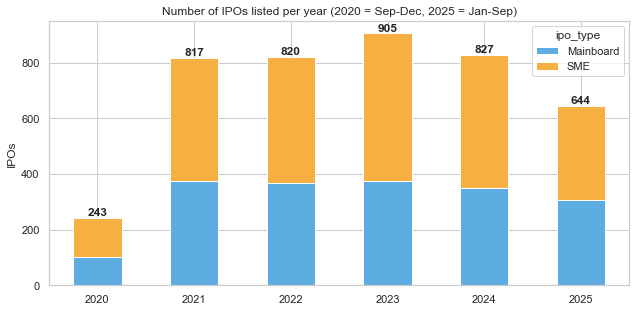

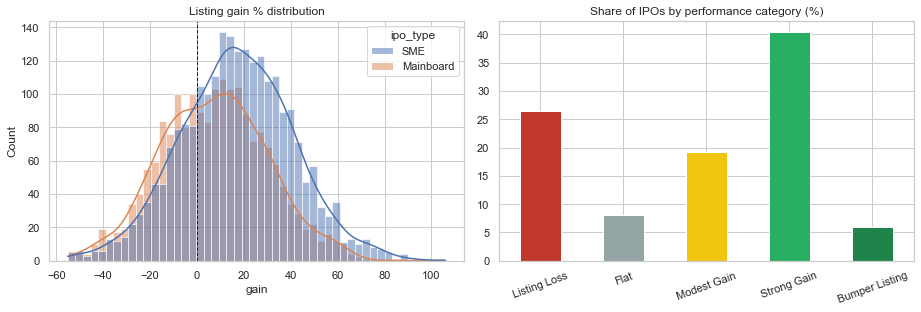

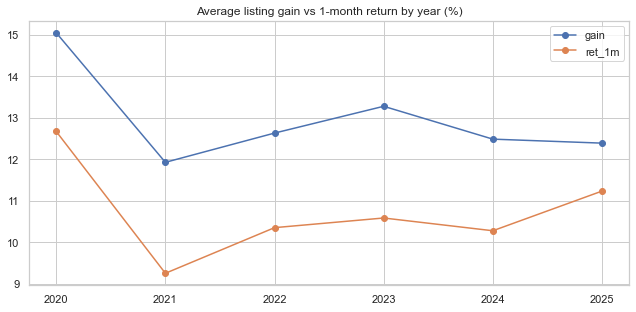

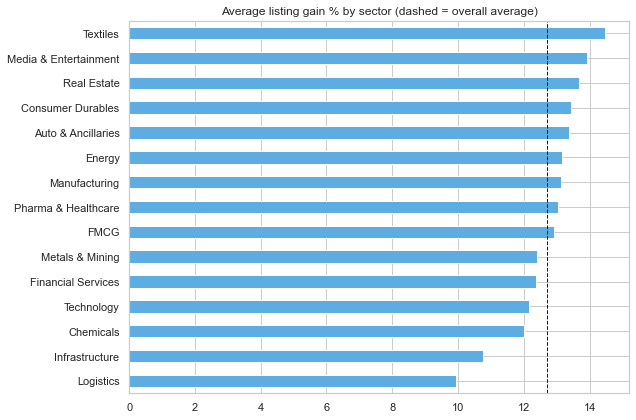

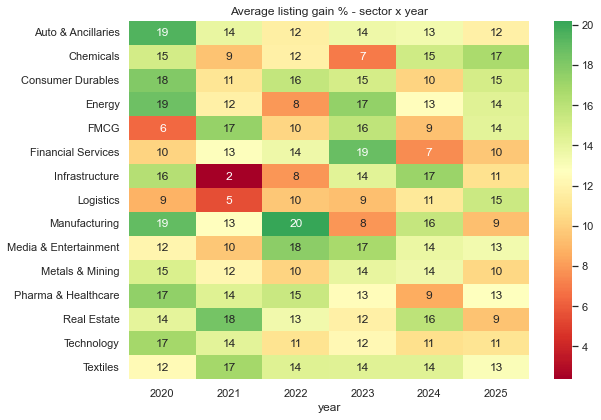

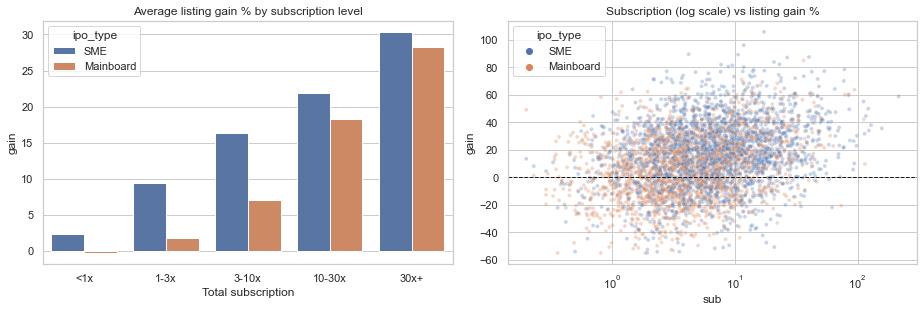

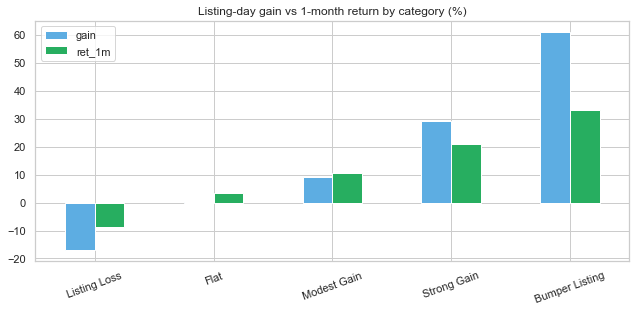

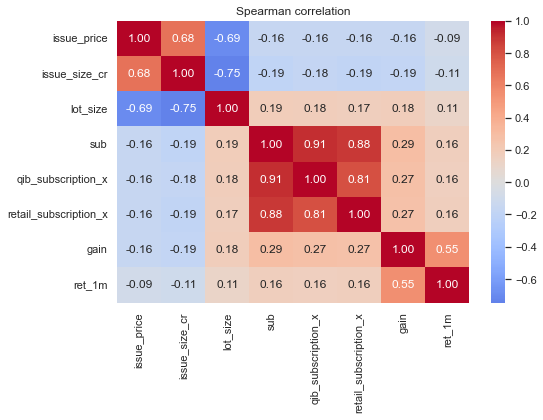

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
_sv = tuple(int(x) for x in sns.__version__.split(".")[:2])
NO_CI = {"errorbar": None} if _sv >= (0, 12) else {"ci": None}     # works on old + new seaborn

# ---------- 1. Load + quick clean ----------
df = pd.read_excel("IPO_Listing_Performance_5yr.xlsx")
df = df.rename(columns={"Listing_Gain_%": "gain", "Return_1M_%": "ret_1m", "Subscription_Times": "sub"})
df.columns = [c.lower() for c in df.columns]

key = df["sector"].str.lower().str.replace(r"[^a-z]", "", regex=True)           # fix sector spellings
df["sector"] = key.map(df.groupby(key)["sector"].agg(lambda s: s.value_counts().index[0]))
df["ipo_type"] = np.where(df["exchange"].str.contains("SME"), "SME", "Mainboard")   # fix type labels
bad = ((df["listing_close_price"] / df["issue_price"] - 1) * 100 - df["gain"]).abs() > 1
df.loc[bad, "issue_price"] = df["listing_close_price"] / (1 + df["gain"] / 100)     # fix 6 wrong prices
df["gain"] = df["gain"].fillna((df["listing_close_price"] / df["issue_price"] - 1) * 100)  # fill 17 blanks

df["year"] = pd.to_datetime(df["listing_date"]).dt.year
cats = ["Listing Loss", "Flat", "Modest Gain", "Strong Gain", "Bumper Listing"]
df["perf"] = pd.cut(df["gain"], [-np.inf, -3, 3, 15, 50, np.inf], labels=cats, right=False)
df["sub_bucket"] = pd.cut(df["sub"], [0, 1, 3, 10, 30, np.inf], right=False,
                          labels=["<1x", "1-3x", "3-10x", "10-30x", "30x+"])

# ---------- 2. Charts ----------
# Chart 1: how many IPOs per year (SME vs Mainboard stacked)
cnt = pd.crosstab(df["year"], df["ipo_type"])
ax = cnt.plot.bar(stacked=True, figsize=(9, 4.5), color=["#5dade2", "#f5b041"], rot=0)
for i, tot in enumerate(cnt.sum(axis=1)):
    ax.text(i, tot + 8, int(tot), ha="center", fontweight="bold")
ax.set_title("Number of IPOs listed per year (2020 = Sep-Dec, 2025 = Jan-Sep)")
ax.set_xlabel(""); ax.set_ylabel("IPOs")
plt.tight_layout(); plt.show()

# Chart 2: distribution of listing gain + category share
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=df, x="gain", hue="ipo_type", bins=50, kde=True, ax=ax[0])
ax[0].axvline(0, color="k", ls="--", lw=1); ax[0].set_title("Listing gain % distribution")
(df["perf"].value_counts(normalize=True).reindex(cats) * 100).plot.bar(
    ax=ax[1], color=["#c0392b", "#95a5a6", "#f1c40f", "#27ae60", "#1e8449"], rot=20)
ax[1].set_title("Share of IPOs by performance category (%)"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

# Chart 3: average listing gain and 1M return by year
yr = df.groupby("year")[["gain", "ret_1m"]].mean()
ax = yr.plot(marker="o", figsize=(9, 4.5))
ax.set_title("Average listing gain vs 1-month return by year (%)"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

# Chart 4: sector average gain
sec = df.groupby("sector")["gain"].mean().sort_values()
plt.figure(figsize=(9, 6))
sec.plot.barh(color="#5dade2")
plt.axvline(df["gain"].mean(), color="k", ls="--", lw=1)
plt.title("Average listing gain % by sector (dashed = overall average)"); plt.ylabel("")
plt.tight_layout(); plt.show()

# Chart 5: sector x year heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df.pivot_table(index="sector", columns="year", values="gain", aggfunc="mean"),
            annot=True, fmt=".0f", cmap="RdYlGn", center=df["gain"].mean())
plt.title("Average listing gain % - sector x year"); plt.ylabel("")
plt.tight_layout(); plt.show()

# Chart 6: subscription vs gain
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=df.dropna(subset=["sub_bucket"]), x="sub_bucket", y="gain", hue="ipo_type", ax=ax[0], **NO_CI)
ax[0].set_title("Average listing gain % by subscription level"); ax[0].set_xlabel("Total subscription")
sns.scatterplot(data=df.dropna(subset=["sub"]), x="sub", y="gain", hue="ipo_type", alpha=0.3, s=15, ax=ax[1])
ax[1].set_xscale("log"); ax[1].axhline(0, color="k", ls="--", lw=1)
ax[1].set_title("Subscription (log scale) vs listing gain %")
plt.tight_layout(); plt.show()

# Chart 7: do gains last? listing gain vs 1M return by category
hold = df.groupby("perf")[["gain", "ret_1m"]].mean().reindex(cats)
ax = hold.plot.bar(figsize=(9, 4.5), color=["#5dade2", "#27ae60"], rot=20)
ax.set_title("Listing-day gain vs 1-month return by category (%)"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

# Chart 8: correlation heatmap
cols = ["issue_price", "issue_size_cr", "lot_size", "sub", "qib_subscription_x",
        "retail_subscription_x", "gain", "ret_1m"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation"); plt.tight_layout(); plt.show()